In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns



In [7]:
df = pd.read_csv("train.csv",encoding = "latin1")
df_test = pd.read_csv("test.csv",encoding = "latin1")
df_test.head()


FileNotFoundError: [Errno 2] No such file or directory: 'train.csv'

In [4]:
col= ["PassengerId","Name","Fare","Cabin"]
df.drop(columns = col,inplace =True)
df_test.drop(columns =col,inplace =True)


NameError: name 'df' is not defined

In [80]:
df.head

,Survived,Pclass,Sex,Age,SibSp,Parch,Ticket,Embarked
0,0,3,male,22.0,1,0,A/5 21171,S
1,1,1,female,38.0,1,0,PC 17599,C
2,1,3,female,26.0,0,0,STON/O2. 3101282,S
3,1,1,female,35.0,1,0,113803,S
4,0,3,male,35.0,0,0,373450,S


In [81]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 8 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Survived  891 non-null    int64  
 1   Pclass    891 non-null    int64  
 2   Sex       891 non-null    object 
 3   Age       714 non-null    float64
 4   SibSp     891 non-null    int64  
 5   Parch     891 non-null    int64  
 6   Ticket    891 non-null    object 
 7   Embarked  889 non-null    object 
dtypes: float64(1), int64(4), object(3)
memory usage: 55.8+ KB


In [82]:
df.describe()


,Survived,Pclass,Age,SibSp,Parch
count,891.000000,891.000000,714.000000,891.000000,891.000000
mean,0.383838,2.308642,29.699118,0.523008,0.381594
std,0.486592,0.836071,14.526497,1.102743,0.806057
min,0.000000,1.000000,0.420000,0.000000,0.000000
25%,0.000000,2.000000,20.125000,0.000000,0.000000
50%,0.000000,3.000000,28.000000,0.000000,0.000000
75%,1.000000,3.000000,38.000000,1.000000,0.000000
max,1.000000,3.000000,80.000000,8.000000,6.000000


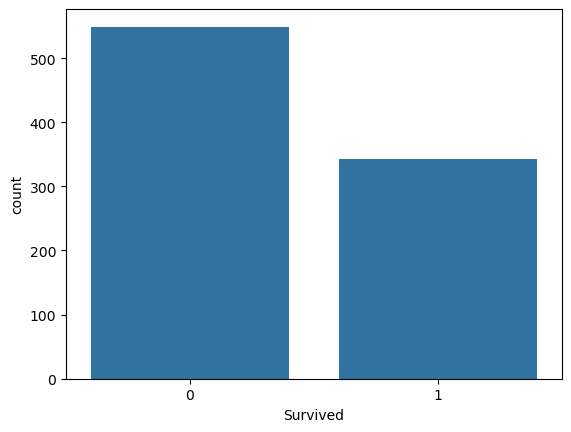

In [83]:
sns.countplot(x ="Survived" , data = df)
plt.show()

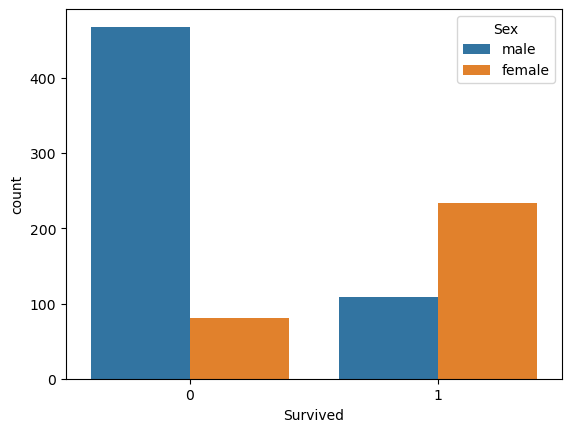

In [84]:
sns.countplot(x ="Survived" ,hue= "Sex",data = df)
plt.show()

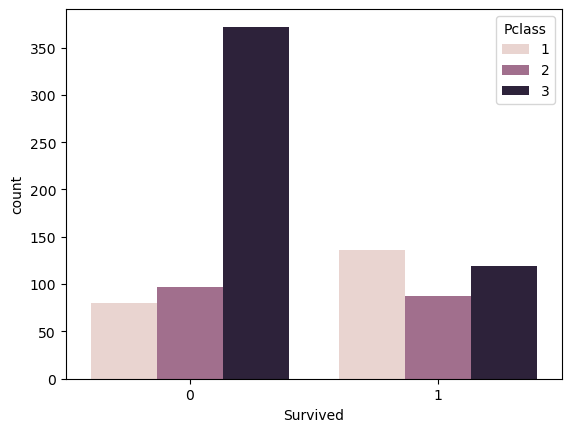

In [85]:
sns.countplot(x ="Survived",hue ="Pclass" , data = df)
plt.show()

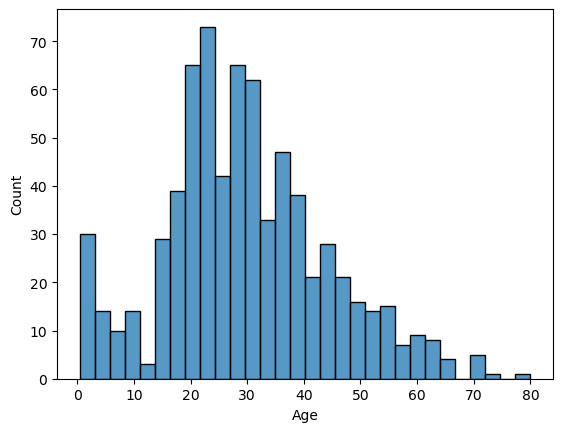

In [86]:
sns.histplot(df["Age"],bins = 30)
plt.show()

In [87]:
df["FamilySize"] = df["SibSp"] + df["Parch"] + 1
df_test["FamilySize"] = df_test["SibSp"] + df_test["Parch"] + 1


In [88]:
df["Age"]=df["Age"].fillna(df["Age"].median()) 
df_test["Age"] = df["Age"].fillna(df_test["Age"].median())

In [89]:
df["Embarked"] = df["Embarked"].fillna(df["Embarked"].mode())
df_test["Embarked"] = df_test["Embarked"].fillna(df_test["Embarked"].mode())



In [90]:
X = df.drop(["Survived"],axis = 1)
y = df["Survived"]

In [91]:
# model train

In [92]:
from sklearn.model_selection import train_test_split
X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42
)


In [93]:
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer

Categorical_Data = ["Sex", "Embarked"]
Numerical_Data = ["Pclass",	"Age", "SibSp",	"Parch",  "FamilySize"]

preprocessor = ColumnTransformer( 
    transformers=[
        ("Cat", OneHotEncoder(handle_unknown="ignore"), Categorical_Data),
        ("Num", "passthrough", Numerical_Data )
    ]
)

In [2]:
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression

model = Pipeline(
    steps = [
        ("preprocessor", preprocessor),
        ("classifier", LogisticRegression(max_iter=1000))
    ]
)
model

NameError: name 'preprocessor' is not defined

In [ ]:
model.fit(X_train, y_train)



In [96]:
y_pred =model.predict(X_val)
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

print("Accuracy", accuracy_score(y_val,y_pred))
print(confusion_matrix(y_val, y_pred))
print(classification_report(y_val, y_pred))

Accuracy 0.8100558659217877
[[91 14]
 [20 54]]
              precision    recall  f1-score   support

           0       0.82      0.87      0.84       105
           1       0.79      0.73      0.76        74

    accuracy                           0.81       179
   macro avg       0.81      0.80      0.80       179
weighted avg       0.81      0.81      0.81       179



In [102]:
model.fit(X,y)
test_pred =model.predict(df_test)


In [120]:
test_raw = pd.read_csv("test.csv")

In [1]:

submission = pd.DataFrame({
    "PassengerId": test_raw["PassengerId"],
    "Survived": test_pred
})


NameError: name 'pd' is not defined

In [123]:
submission.to_csv("submission.csv", index=False)

In [124]:
import pickle
with open("titanic_model.pkl", "wb") as file:
    pickle.dump(model, file)
